In [ ]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [ ]:
# Load 028 transect
transect = load_transect(config.TRANSECT_028_OUTPUT)

transect.list_files()

# Select 028_5 for NDI analysis
cube = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
# cube.describe()

In [ ]:
cube.apply_illumination_correction_v2()

In [ ]:
cube.import_rois("./ROIs/028_new.json")
cube.list_rois()

roi_1 = [
    "1_halo",
    "1_arms",
    "1_dark",
    "1_bomb",
    "sediment",
]
roi_2 = [
    "2_halo",
    "rust",
    "sediment",
    "2_dark",
    "2_bomb",
]
roi_3 = [
    "3_halo",
    "3_dark",
    "sediment",
    "3_bomb",
]
roi_pit = [
    "sediment",
    "dark_pits",
]

roi_halo = [
    "sediment",
    "1_halo",
    "2_halo",
    "3_halo",
]

roi_dark = [
    "sediment",
    "1_dark",
    "2_dark",
    "3_dark",
]

roi_bomb = [
    "sediment",
    "1_bomb",
    "2_bomb",
    "3_bomb",
]


roi_training_binary = [
    "sediment",
    "rust",
]

roi_training = [
    "sediment",
    "rust",
    "1_dark",
    "2_dark",
    "3_dark",
    "1_halo",
    "2_halo",
    "3_halo",
]

In [ ]:
# Define crop regions (UPDATED coordinates from user)
crop_regions = [
    {
        "name": "Crop 1 (Bomb 2 - Rust)",
        "label": "b",
        "track": 1258,
        "slit": 250,  # UPDATED from 212
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 2 (Bomb 3)",
        "label": "c",
        "track": 5592,
        "slit": 700,  # UPDATED from 765
        "width": 500,
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 3 (Bomb 1)",
        "label": "a",
        "track": 5160,
        "slit": 613,
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 4 (Dark pits)",
        "label": "d",
        "track": 717,
        "slit": 385,
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
]

In [ ]:
# # 🔧 MONKEYPATCH: Clean image output (no axes, labels, titles, colorbars)
# # This removes all plot decorations to get JUST THE IMAGE

# import matplotlib.pyplot as plt
# from utils.uhi.georef import CombinedTransectCube

# # Store original plot_rgb method
# _original_plot_rgb = CombinedTransectCube.plot_rgb


# def plot_rgb_clean(*args, **kwargs):
#     """
#     Wrapper that calls original plot_rgb but removes all decorations.
#     Results in clean image output - JUST THE FIGURE, nothing else.
#     """
#     # Call original function
#     result = _original_plot_rgb(*args, **kwargs)

#     # Get current figure and axes
#     fig = plt.gcf()
#     ax = plt.gca()

#     # Remove ALL decorations for clean image output
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.set_title("")
#     ax.axis("off")  # This removes tick marks, labels, and frame

#     # Remove ALL text annotations
#     for txt in ax.texts:
#         txt.set_visible(False)

#     # Remove colorbar if present (any extra axes)
#     if len(fig.axes) > 1:
#         for axis in fig.axes[1:]:
#             axis.remove()

#     # Remove whitespace around image
#     fig.tight_layout(pad=0)
#     plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

#     return result


# # Apply monkeypatch
# CombinedTransectCube.plot_rgb = plot_rgb_clean

# print("✅ Clean image monkeypatch applied!")
# print("   All plots will show JUST THE IMAGE - no axes, labels, titles, or colorbars")
# print("   To revert: restart kernel")

In [ ]:
# Plot all crop regions defined above
import matplotlib.pyplot as plt
from pathlib import Path

for crop in crop_regions:
    print(f"\n{'='*60}")
    print(f"📍 {crop['name']} (label: {crop['label']})")
    print(f"   Track: {crop['track']}, Slit: {crop['slit']}")
    print(f"   Width: {crop['width']}, Aspect Ratio: {crop['aspect_ratio']}")
    print(f"{'='*60}\n")

    # Determine which ROI collection to use based on crop name
    if "Bomb 1" in crop["name"]:
        roi_collection = roi_1
    elif "Bomb 2" in crop["name"]:
        roi_collection = roi_2
    elif "Bomb 3" in crop["name"]:
        roi_collection = roi_3
    elif "Dark pits" in crop["name"]:
        roi_collection = roi_pit
    else:
        roi_collection = None

    # === PLOT RGB WITHOUT ROIs (clean image) ===
    save_path = f"../images_for_publication/028_mosaics/{crop['label']}.pdf"

    # Monkeypatch plt.show() to clean up before display and save
    _original_show = plt.show

    def _cleanup_then_show(*args, **kwargs):
        fig = plt.gcf()
        ax = fig.axes[0]  # Get main image axes
        ax.axis("off")  # Remove axes, ticks, labels

        # Remove legend if present
        legend = ax.get_legend()
        if legend:
            legend.remove()

        # Remove colorbar/other axes
        if len(fig.axes) > 1:
            for a in fig.axes[1:]:
                a.remove()

        ax.set_title("")
        fig.suptitle("")

        # Remove all margins and whitespace
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

        # Save to file
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
        print(f"   ✅ Saved: {save_path}")

        _original_show(*args, **kwargs)

    plt.show = _cleanup_then_show
    try:
        cube.plot_rgb(
            use_corrected=True,
            flip_axes=True,
            flip_horizontal=True,
            crop_center_track=crop["track"],
            crop_center_slit=crop["slit"],
            crop_width=crop["width"],
            show_file_boundaries=False,
            crop_aspect_ratio=crop["aspect_ratio"],
            display_aspect_ratio=4.0,
        )
    finally:
        plt.show = _original_show

    # === PLOT RGB WITH ROIs OVERLAY (clean image with ROIs) ===
    if roi_collection:
        save_path_roi = f"../images_for_publication/028_mosaics/{crop['label']}_roi.pdf"

        # Monkeypatch plt.show() again for ROI version
        def _cleanup_then_show_roi(*args, **kwargs):
            fig = plt.gcf()
            ax = fig.axes[0]  # Get main image axes
            ax.axis("off")  # Remove axes, ticks, labels

            # Remove legend if present
            legend = ax.get_legend()
            if legend:
                legend.remove()

            # Remove colorbar/other axes
            if len(fig.axes) > 1:
                for a in fig.axes[1:]:
                    a.remove()

            ax.set_title("")
            fig.suptitle("")

            # Remove all margins and whitespace
            fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

            # Save to file
            Path(save_path_roi).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path_roi, bbox_inches="tight", pad_inches=0)
            print(f"   ✅ Saved: {save_path_roi}")

            _original_show(*args, **kwargs)

        plt.show = _cleanup_then_show_roi
        try:
            cube.plot_rgb(
                use_corrected=True,
                flip_axes=True,
                flip_horizontal=True,
                crop_center_track=crop["track"],
                crop_center_slit=crop["slit"],
                crop_width=crop["width"],
                show_file_boundaries=False,
                crop_aspect_ratio=crop["aspect_ratio"],
                display_aspect_ratio=4.0,
                roi_collection=roi_collection,
                roi_marker_size=5,
                roi_legend_markersize=20,
                roi_marker_edgewidth=0,
                roi_overlay_mode="solid",
                roi_solid_pixel_size=3,
            )
        finally:
            plt.show = _original_show

print(f"\n✅ All {len(crop_regions)} crop regions plotted and saved!")

In [ ]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
)

cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Normalized pseudo-reflectance intensity",  # Custom y-axis label
)

cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="First derivative of pseudo-reflectance (dR/dλ)",  # Custom y-axis label
    derivative_order=1,
)

In [ ]:
# 🎨 CONFIGURE LEGEND ORDER AND NAMES
# =====================================

# 1. Define which ROIs to exclude from the plot
exclude_rois = ["dark_pits_multiple"]  # Add any ROI names you want to hide

# 2. Define custom display names (optional - leave empty {} to use original names)
roi_display_names = {
    "1_bomb": "bomb a",
    "1_dark": "dark a",
    "1_halo": "halo a",
    "2_bomb": "bomb b",
    "2_dark": "dark b",
    "2_halo": "halo b",
    "3_bomb": "bomb c",
    "3_dark": "dark c",
    "3_halo": "halo c",
    "sediment": "sediment",
    "rust": "rust",
    "1_arms": "radial features a",
    "dark_pits": "dark d",
}

# 3. Define the EXACT ORDER you want in the legend (top to bottom)
legend_order = [
    "1_bomb",
    "1_dark",
    "1_halo",
    "1_arms",
    "2_bomb",
    "2_dark",
    "2_halo",
    "rust",
    "3_bomb",
    "3_dark",
    "3_halo",
    "sediment",
    "dark_pits",
]


# 4. Filter and reorder ROIs based on your settings
def get_ordered_rois(roi_list):
    """Filter, rename, and reorder ROIs based on configuration above."""
    # Filter out excluded ROIs
    filtered = [roi for roi in roi_list if roi not in exclude_rois]

    # Create ordered list based on legend_order
    ordered = []
    for roi_name in legend_order:
        if roi_name in filtered:
            ordered.append(roi_name)

    # Add any remaining ROIs not in legend_order (at the end)
    remaining = [roi for roi in filtered if roi not in ordered]
    ordered.extend(remaining)

    return ordered


print("✅ Legend configuration ready!")
print(f"   Excluded ROIs: {exclude_rois}")
print(f"   Custom names defined: {len(roi_display_names)} ROIs")
print(f"   Legend order: {len(legend_order)} ROIs specified")

Available ROIs: ['rust', 'sediment', 'bomb a', 'dark a', 'halo a', 'radial features a', 'bomb b', 'dark b', 'halo b', 'bomb c', 'dark c', 'halo c', 'dark d']

Desired order: ['rust', 'sediment', 'bomb a', 'dark a', 'halo a', 'radial features a', 'bomb b', 'dark b', 'halo b', 'bomb c', 'dark c', 'halo c', 'dark d']

Ordered collection keys: ['rust', 'sediment', 'bomb a', 'dark a', 'halo a', 'radial features a', 'bomb b', 'dark b', 'halo b', 'bomb c', 'dark c', 'halo c', 'dark d']

✅ Saved spectrum plot: ../images_for_publication/028_mosaics/028_roi_pseudo.pdf


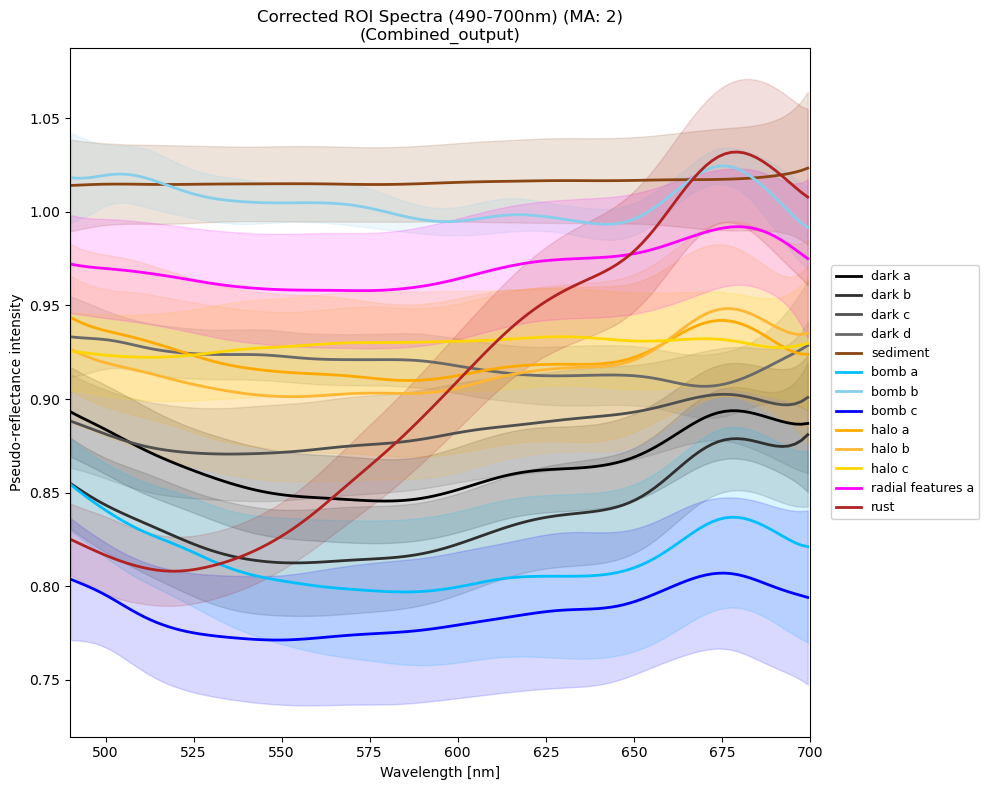

✅ Saved spectrum plot: ../images_for_publication/028_mosaics/028_roi_normalized.pdf


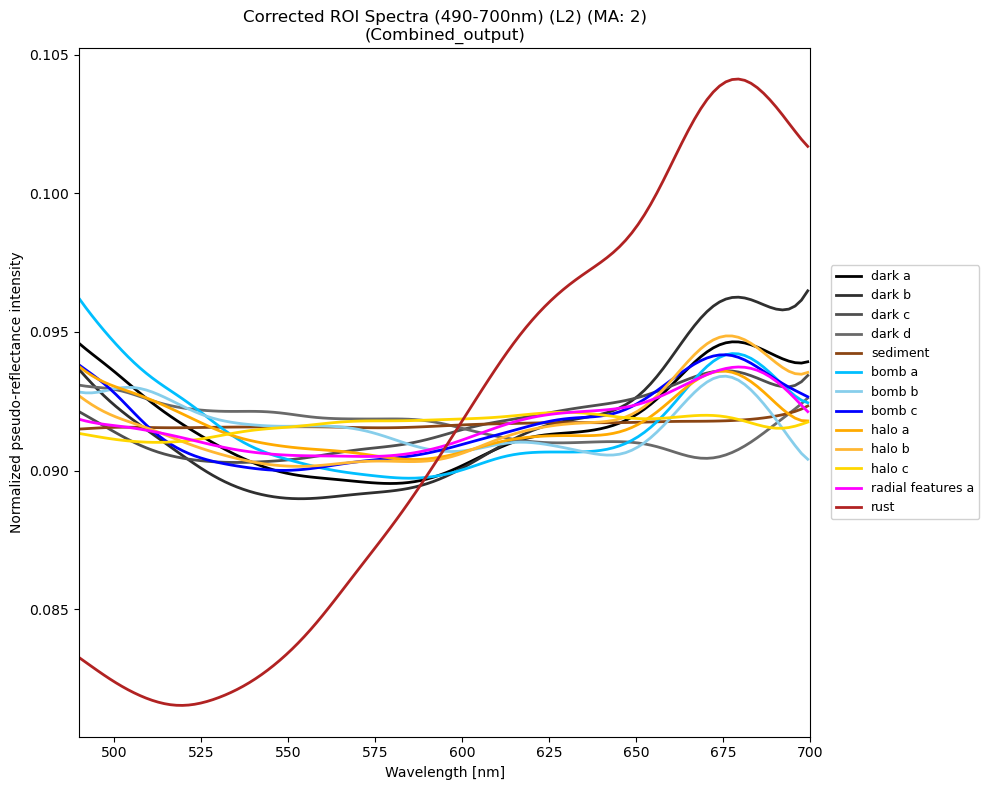

✅ Saved spectrum plot: ../images_for_publication/028_mosaics/028_roi_derivative.pdf


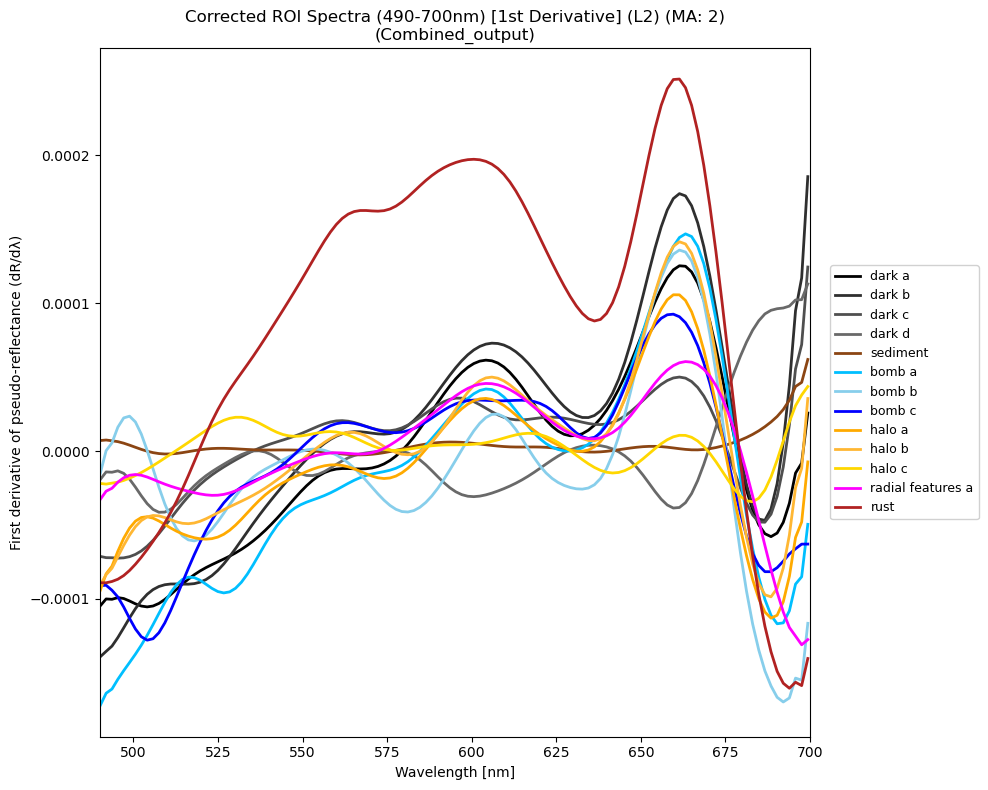

In [ ]:
# 📊 Plot spectrum with custom legend order
# ============================================

# Get all ROIs currently loaded
all_rois = list(cube.roi_collection.keys())
print(f"Available ROIs: {all_rois}\n")

# Apply filtering and ordering
ordered_roi_names = get_ordered_rois(all_rois)
print(f"Desired order: {ordered_roi_names}\n")

# CREATE NEW ORDERED ROI COLLECTION (this controls legend order!)
# Python 3.7+ dicts preserve insertion order
ordered_roi_collection = {}
for roi_name in ordered_roi_names:
    if roi_name in cube.roi_collection:
        # Use custom display name if available, otherwise original name
        display_name = roi_display_names.get(roi_name, roi_name)
        ordered_roi_collection[display_name] = cube.roi_collection[roi_name]

print(f"Ordered collection keys: {list(ordered_roi_collection.keys())}\n")

# Print pixel counts for each ROI
print("📊 Pixel counts per ROI:")
print("=" * 50)
total_pixels = 0
for display_name, pixels in ordered_roi_collection.items():
    pixel_count = len(pixels)
    total_pixels += pixel_count
    print(f"{display_name:25s}: {pixel_count:6d} pixels")
print("=" * 50)
print(f"{'Total':25s}: {total_pixels:6d} pixels\n")

# Temporarily replace ROI collection
original_collection = cube.roi_collection
cube.roi_collection = ordered_roi_collection

# Plot with custom order - legend will match the dictionary order!
cube.plot_spectrum(
    roi_names="all",  # Now "all" will iterate in our custom order
    use_corrected=True,
    wavelength_range=[490, 700],
    normalize_method=None,
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",
    show_grid=False,
    save_file="../images_for_publication/028_mosaics/028_roi_pseudo.pdf",
    # legend_loc="lower left",
)

cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Normalized pseudo-reflectance intensity",  # Custom y-axis label
    show_grid=False,
    save_file="../images_for_publication/028_mosaics/028_roi_normalized.pdf",
)

cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="First derivative of pseudo-reflectance (dR/dλ)",  # Custom y-axis label
    derivative_order=1,
    show_grid=False,
    save_file="../images_for_publication/028_mosaics/028_roi_derivative.pdf",
)

# get the leaf image

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 9380 → local track 9380, slit 400
   Aspect ratio correction: 10.00:1 (track:slit)
   Slit pixels: 700, Track pixels: 70
🔍 Crop applied: track [9345:9415], slit [50:750]
   Resulting shape: (70, 700, 3)
📊 Extent: x=[50, 750], y=[9345, 9415]
📐 Image shape after transformations: (70, 700, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=outside, roi_overlay_mode=solid
✅ Saved: ../images_for_publication/028_mosaics/leaf.pdf


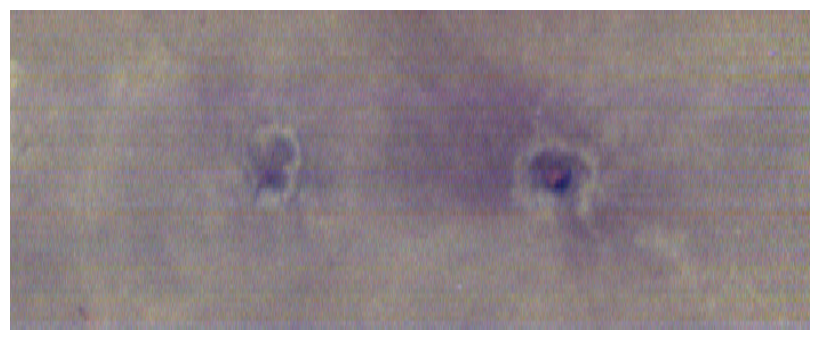

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Save path for the leaf image
save_path = "../images_for_publication/leaf.pdf"

# Monkeypatch plt.show() to clean up before display and save
_original_show = plt.show


def _cleanup_then_show(*args, **kwargs):
    fig = plt.gcf()
    ax = fig.axes[0]  # Get main image axes
    ax.axis("off")  # Remove axes, ticks, labels

    # Remove legend if present
    legend = ax.get_legend()
    if legend:
        legend.remove()

    # Remove colorbar/other axes
    if len(fig.axes) > 1:
        for a in fig.axes[1:]:
            a.remove()

    ax.set_title("")
    fig.suptitle("")

    # Remove all margins and whitespace
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

    # Save to file
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    print(f"✅ Saved: {save_path}")

    _original_show(*args, **kwargs)


plt.show = _cleanup_then_show
try:
    cube.plot_rgb(
        use_corrected=True,
        flip_axes=True,
        flip_horizontal=True,
        crop_center_track=9380,
        crop_center_slit=400,
        crop_width=700,
        show_file_boundaries=False,
        crop_aspect_ratio=10,
        display_aspect_ratio=4.0,
        roi_legend_loc="outside",
        roi_marker_size=5,
        roi_legend_markersize=15,
        roi_marker_edgewidth=0,
        roi_overlay_mode="solid",  # ← Enable solid mode
        roi_solid_pixel_size=1,
    )
finally:
    plt.show = _original_show